In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, os

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_curve, auc)

df = pd.read_csv('../data/raw/rice.csv') 
print(df.shape)
df.head()


(3810, 8)


,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231.0,525.578979,229.749878,85.093788,0.928882,15617.0,0.572896,Cammeo
1,14656.0,494.311005,206.020065,91.730972,0.895405,15072.0,0.615436,Cammeo
2,14634.0,501.122009,214.106781,87.768288,0.912118,14954.0,0.693259,Cammeo
3,13176.0,458.342987,193.337387,87.448395,0.891861,13368.0,0.640669,Cammeo
4,14688.0,507.166992,211.743378,89.312454,0.906691,15262.0,0.646024,Cammeo


In [3]:

df['Class_encoded'] = df['Class'].astype('category').cat.codes


In [4]:
X = df.drop(columns=['Class', 'Class_encoded'])   # Input data

y = df['Class_encoded']   # Output data

X_train, X_test, y_train, y_test = train_test_split(
    X, y,                 # Input and output
    test_size=0.2,        # 20% for testing
    random_state=42,      # Same split every time
    stratify=y            # Keep class balance
)

print("Train:", X_train.shape, " Test:", X_test.shape)  # Show data size

Train: (3048, 7)  Test: (762, 7)


In [5]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

param_grid = [
    {'solver': ['svd']},
    {'solver': ['lsqr', 'eigen'], 'shrinkage': ['auto', 0.1, 0.5, None]}
]

grid = GridSearchCV(LinearDiscriminantAnalysis(), param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
best_params = grid.best_params_
print("Best params:", best_params)
print(f"Best CV F1-score: {grid.best_score_:.4f}")


Best params: {'solver': 'svd'}
Best CV F1-score: 0.9435


Test Accuracy : 0.9147
Test Precision: 0.9024
Test Recall   : 0.9541
Test F1-score : 0.9275

              precision    recall  f1-score   support

      Cammeo       0.93      0.86      0.90       326
    Osmancik       0.90      0.95      0.93       436

    accuracy                           0.91       762
   macro avg       0.92      0.91      0.91       762
weighted avg       0.92      0.91      0.91       762



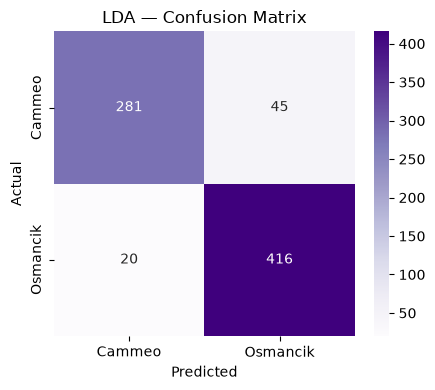

In [6]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Test Accuracy : {acc:.4f}")
print(f"Test Precision: {prec:.4f}")
print(f"Test Recall   : {rec:.4f}")
print(f"Test F1-score : {f1:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Cammeo', 'Osmancik']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Cammeo', 'Osmancik'], yticklabels=['Cammeo', 'Osmancik'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('LDA — Confusion Matrix')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/lda_confusion_matrix.png', dpi=150)
plt.show()


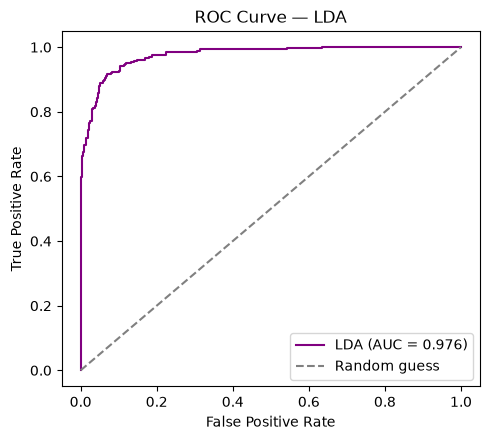

In [7]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5, 4.5))
plt.plot(fpr, tpr, label=f'LDA (AUC = {roc_auc:.3f})', color='purple')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — LDA')
plt.legend()
plt.tight_layout()
plt.savefig('../results/eda_visualizations/lda_roc_curve.png', dpi=150)
plt.show()


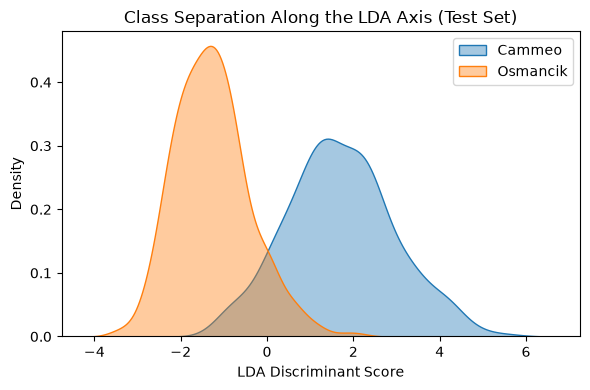

In [8]:
# LDA for a binary problem reduces the data to 1 discriminant component — plot its
# distribution per class to see how well-separated the classes are along that axis.
X_lda = best_model.transform(X_test)

plt.figure(figsize=(6, 4))
for cls, label in [(0, 'Cammeo'), (1, 'Osmancik')]:
    sns.kdeplot(X_lda[y_test == cls].ravel(), label=label, fill=True, alpha=0.4)
plt.xlabel('LDA Discriminant Score')
plt.title('Class Separation Along the LDA Axis (Test Set)')
plt.legend()
plt.tight_layout()
plt.savefig('../results/eda_visualizations/lda_discriminant_axis.png', dpi=150)
plt.show()
